In [11]:
import os
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from tqdm import tqdm
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from torch.optim.lr_scheduler import LambdaLR

In [12]:
# === Config ===
train_csv = 'csv/train.csv'
val_csv = 'csv/val.csv'
test_csv = 'csv/test.csv'
img_size = 224
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [13]:
# === Dataset ===
class SeasonDataset(Dataset):
    def __init__(self, csv_file, transform=None, label_encoder=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.le = label_encoder or LabelEncoder()
        self.data['label_encoded'] = self.le.fit_transform(self.data['label'])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join('', row['file_path'])
        label = row['label_encoded']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [14]:
# === Transforms ===
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# === Label Encoder Shared ===
all_labels = pd.read_csv(train_csv)['label'].tolist()
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

# === Load Data ===
train_dataset = SeasonDataset(train_csv, transform, label_encoder)
val_dataset = SeasonDataset(val_csv, transform, label_encoder)
test_dataset = SeasonDataset(test_csv, transform, label_encoder)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

In [15]:
# === Model ===
model = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(label_encoder.classes_))
model = model.to(device)

# === Loss & Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Warm-up over the first 5 epochs
def warmup_lambda(epoch):
    if epoch < 5:
        return (epoch + 1) / 5
    else:
        return 1.0

scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)

# === Training Loop ===
def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to C:\Users\Kyojuro/.cache\torch\hub\checkpoints\efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:02<00:00, 11.5MB/s]


In [16]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0
epochs_no_improve = 0
patience = 5
epochs = 30

print("Training with full tracking...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # === Validation ===
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss = criterion(outputs, labels)
            val_running_loss += val_loss.item()

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train: Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val: Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    # === Save best model ===
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "seasonal_model_best.pth")
        print("Best model saved!")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    scheduler.step()

    # === Early stopping ===
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

Training with full tracking...


100%|██████████| 62/62 [01:44<00:00,  1.68s/it]


Epoch 1/30 | Train: Loss=152.4590, Acc=0.1314 | Val: Loss=19.2414, Acc=0.2541
Best model saved!


100%|██████████| 62/62 [01:44<00:00,  1.68s/it]


Epoch 2/30 | Train: Loss=142.7215, Acc=0.3112 | Val: Loss=16.8123, Acc=0.3984
Best model saved!


...

Epoch 12/30 | Train: Loss=23.5636, Acc=0.8737 | Val: Loss=6.7893, Acc=0.7175
No improvement for 3 epoch(s)


100%|██████████| 62/62 [04:09<00:00,  4.02s/it]


Epoch 13/30 | Train: Loss=20.4691, Acc=0.8948 | Val: Loss=6.9715, Acc=0.7033
No improvement for 4 epoch(s)


100%|██████████| 62/62 [03:59<00:00,  3.87s/it]


Epoch 14/30 | Train: Loss=17.4376, Acc=0.9085 | Val: Loss=7.0363, Acc=0.7236
No improvement for 5 epoch(s)
Early stopping triggered.


In [17]:
# === Final Test Accuracy ===
test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7175


In [18]:
model.load_state_dict(torch.load('seasonal_model_best.pth'))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

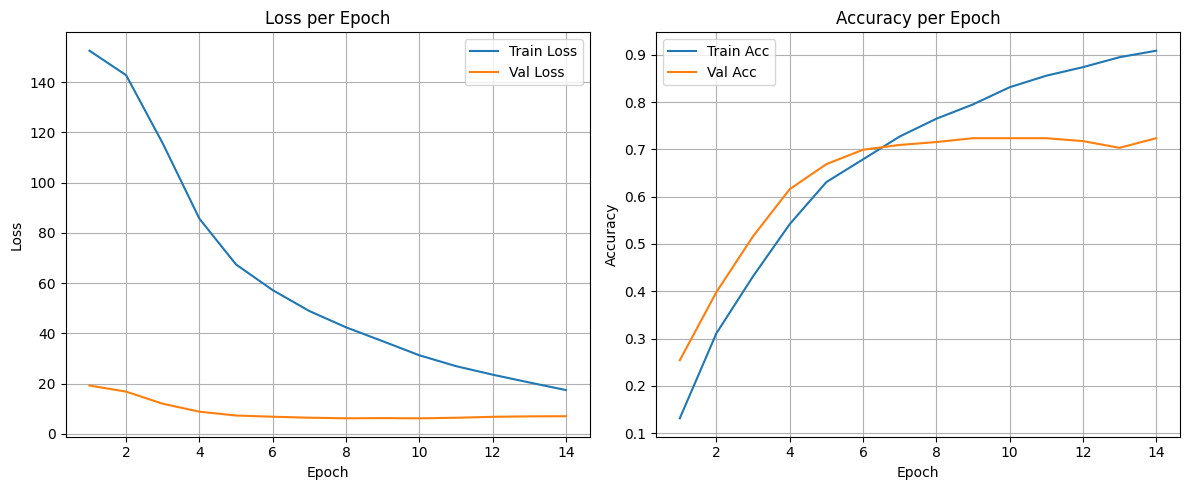

In [19]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc')
plt.plot(epochs_range, val_accuracies, label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

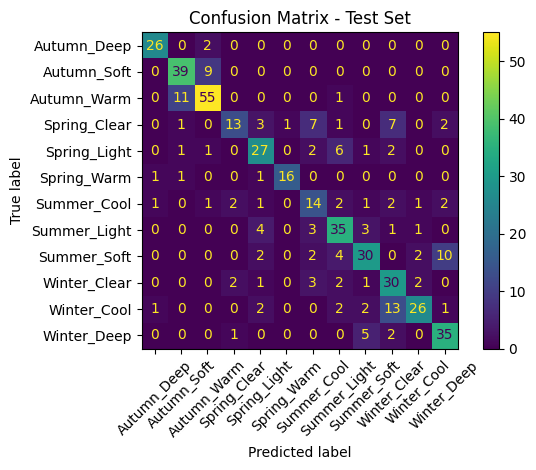

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load("seasonal_model_best.pth"))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()